In [1]:
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import GridSearchCV, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Lasso
from xgboost import XGBRegressor
import numpy as np

X, y = fetch_california_housing(return_X_y=True)
print("데이터 크기:", X.shape)

데이터 크기: (20640, 8)


In [3]:
lasso_pipe = Pipeline([("sc", StandardScaler()), ("model", Lasso(alpha=0.1, max_iter=5000))])
lasso_r2 = cross_val_score(lasso_pipe, X, y, scoring="r2", cv=5)
lasso_mse = -cross_val_score(lasso_pipe, X, y, scoring="neg_mean_squared_error", cv=5).mean()
print(f"lasso  | MSE={lasso_mse:.3f} | R^2={lasso_r2.mean():.3f}")

lasso  | MSE=0.711 | R^2=0.431


In [6]:
pipe = Pipeline([("sc", StandardScaler()), ("model", XGBRegressor(random_state=42))])
param_grid = {
    "model__n_estimators": [300, 500],
    "model__max_depth": [4, 6],
    "model__learning_rate": [0.05, 0.1],
}
grid = GridSearchCV(pipe, param_grid, scoring="neg_mean_squared_error", cv=5)
grid.fit(X, y)

print("최적:", grid.best_params_)
print(f"XGBoost | MSE={-grid.best_score_:.3f}")
xgb_r2 = cross_val_score(grid.best_estimator_, X, y, scoring="r2", cv=5)
print(f"XGBoost | R^2={xgb_r2.mean():.3f}")

최적: {'model__learning_rate': 0.1, 'model__max_depth': 4, 'model__n_estimators': 300}
XGBoost | MSE=0.391
XGBoost | R^2=0.689


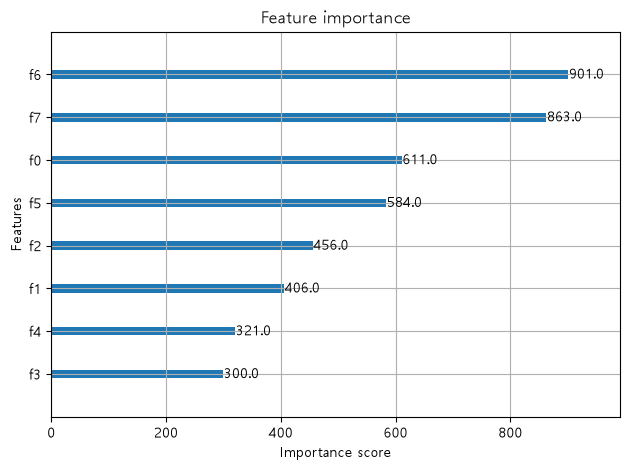

In [10]:
import matplotlib.pyplot as plt
plt.rcParams['font.family'] = 'Malgun Gothic'   # Windows 기본 한글 폰트
plt.rcParams['axes.unicode_minus'] = False       # 마이너스(-) 깨짐 방지

from xgboost import plot_importance

best_model = grid.best_estimator_.named_steps["model"]
plot_importance(best_model)
plt.tight_layout()
plt.show()


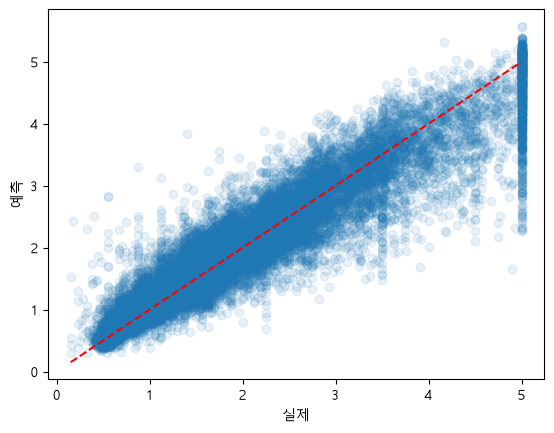

In [11]:
pred = grid.best_estimator_.predict(X)
plt.scatter(y, pred, alpha=0.1)
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--')  # 완벽예측선
plt.xlabel("실제"); plt.ylabel("예측"); plt.show()
